# Extract Planck Gal mask:

1. First download the Planck galactic mask from the Planck Legacy Archive: https://irsa.ipac.caltech.edu/data/Planck/release_2/ancillary-data/previews/HFI_Mask_GalPlane-apo2_2048_R2.00/index.html
2. Produce a real mask (0 or 1) instead of having a apodization (maybe these masks already exist ..) (HFI_Mask_GalPlane-apo0_2048_R2.00 does not give the exact same shape of mask...)
2. Convert this heavy file into a nside=256 maps in the same coordinates system than DESI observations (Galactic -> equatorial).

In [3]:
import healpy as hp
import numpy as np
import fitsio
import matplotlib.pyplot as plt

import sys
sys.path.append('/global/homes/e/edmondc/Software/regressis/regressis')
from regressis.plot import plot_moll

In [7]:
f = fitsio.FITS('HFI_Mask_GalPlane-apo2_2048_R2.00.fits')[1]

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


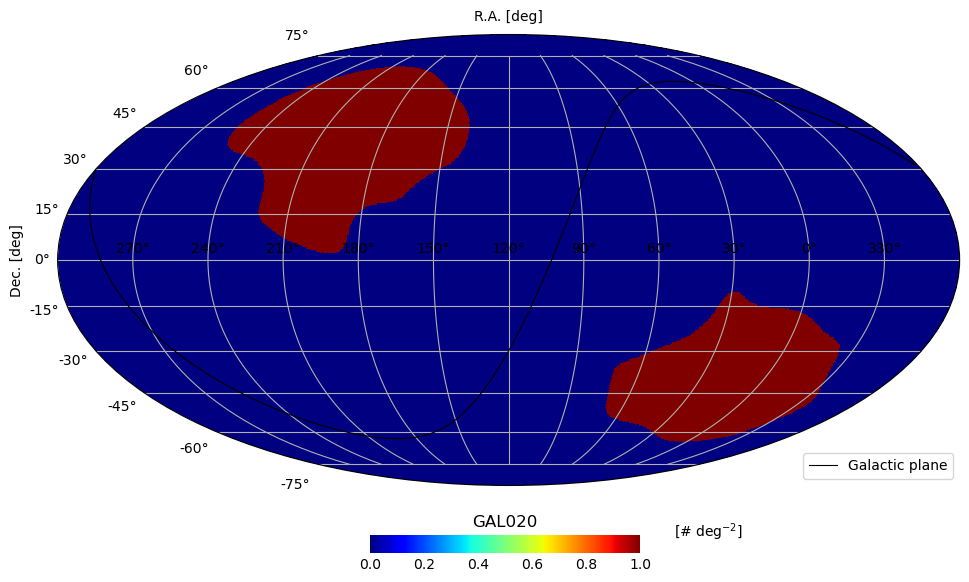

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


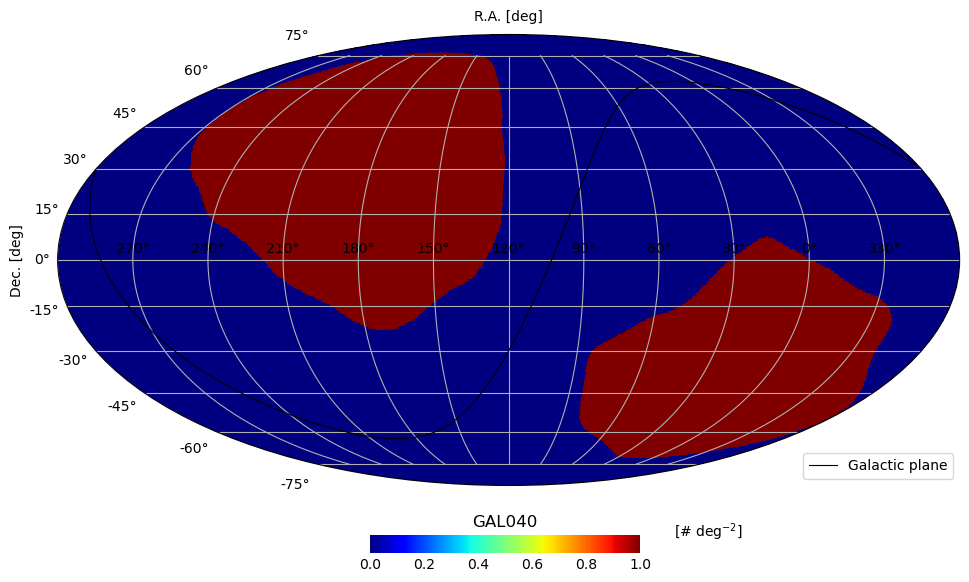

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


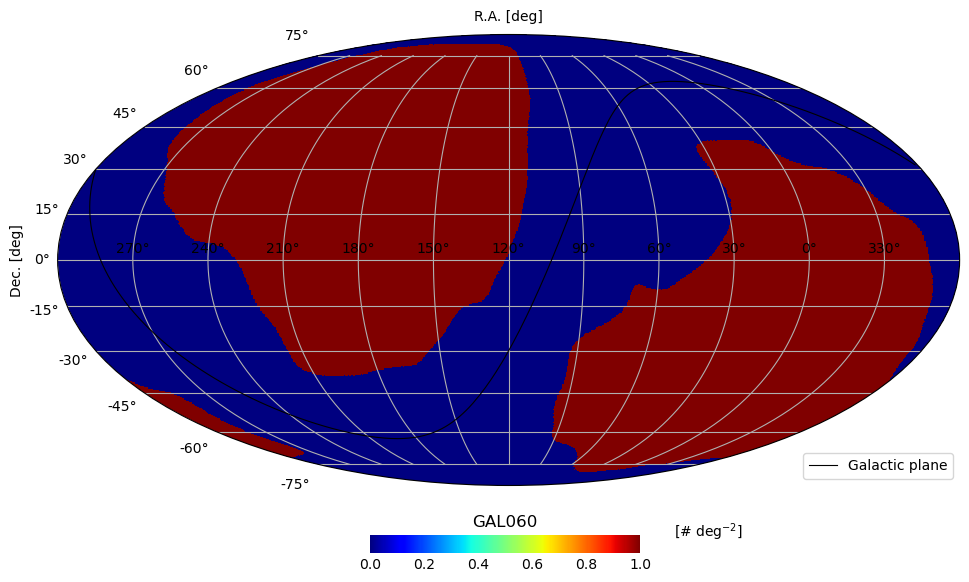

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


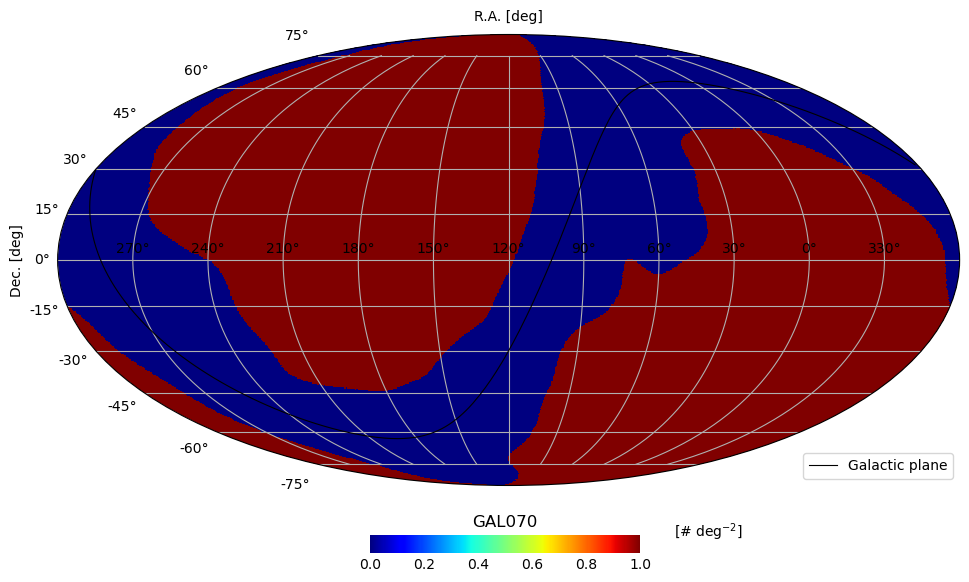

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


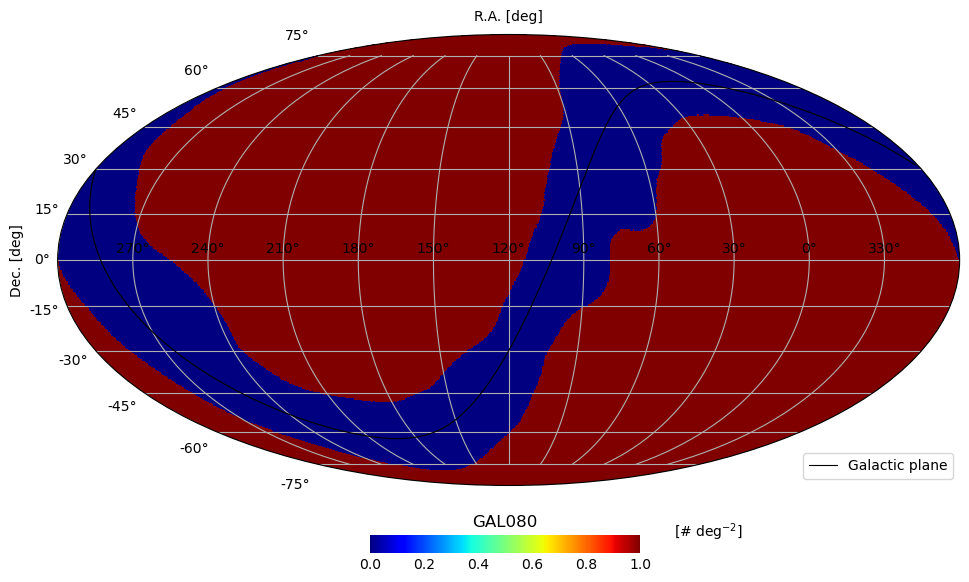

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


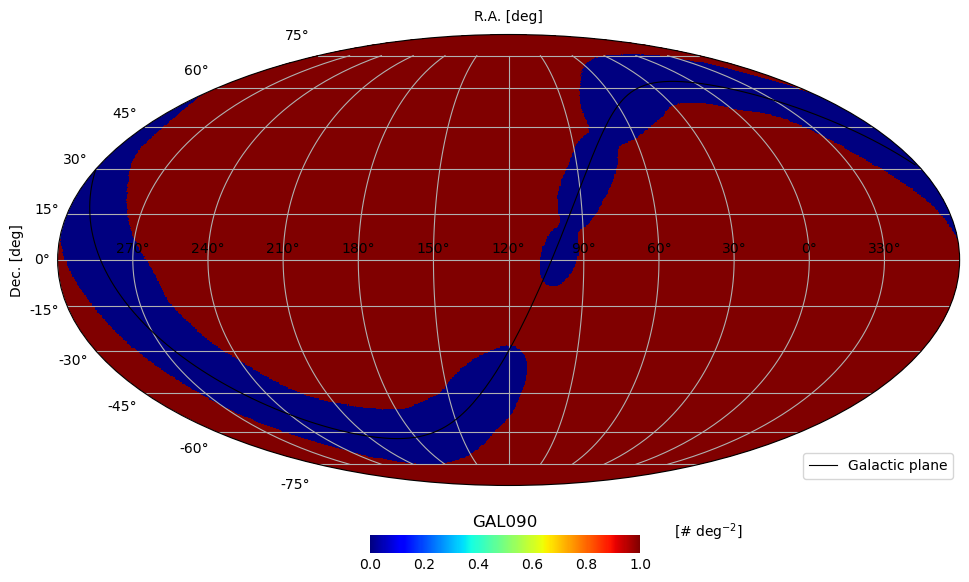

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


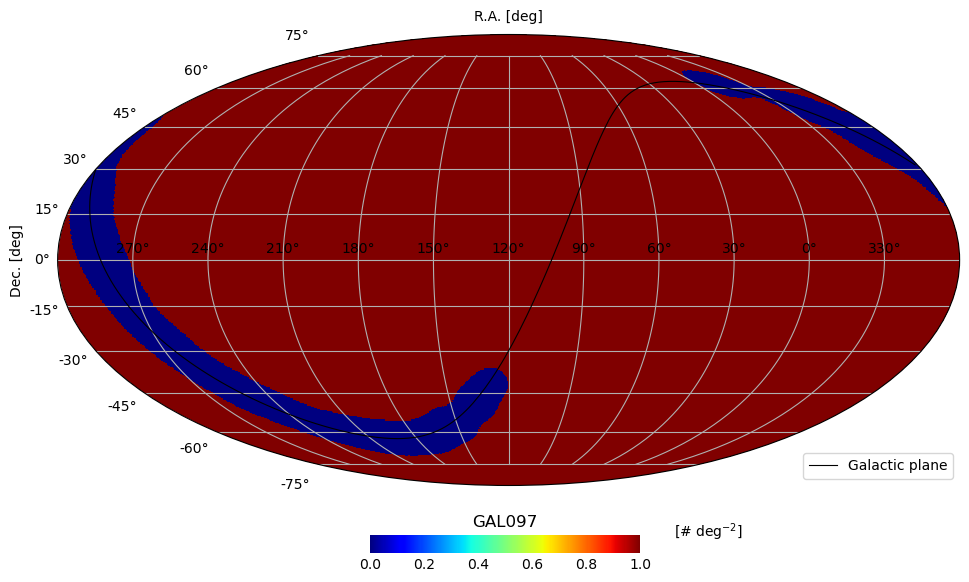

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


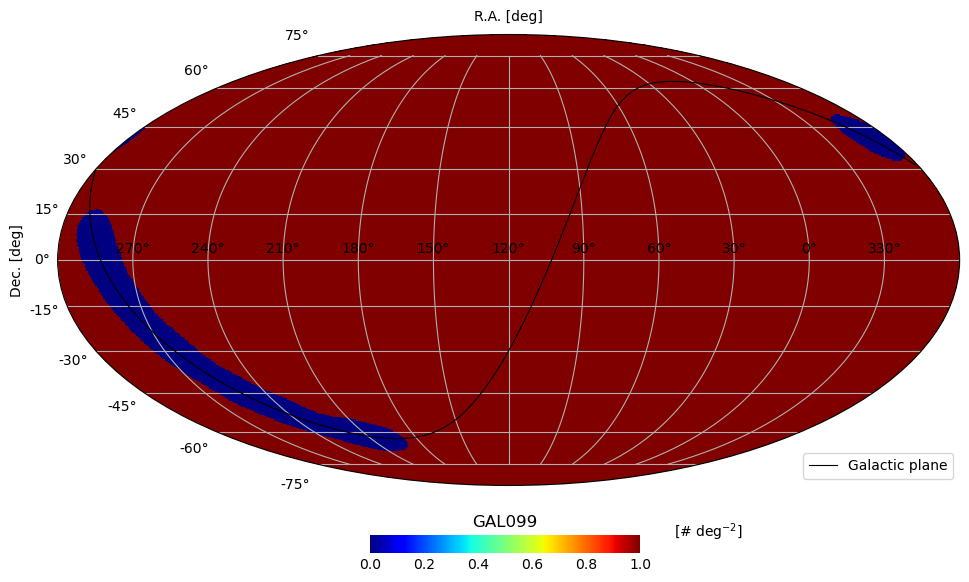

In [39]:
new_maps = {}

# All you want to know is here: https://www.zonca.dev/posts/2021-03-11-rotate-maps-healpy.html
rot_gal2eq = hp.Rotator(coord="GC") 

for name in f.get_colnames():
    mm = hp.ud_grade(f[name][:], nside_out=256, order_in='NESTED')
    mm = hp.reorder(rot_gal2eq.rotate_map_pixel(hp.reorder(mm, n2r=True)), r2n=True)
    new_maps[name] = (mm > 0.5)
    plot_moll(new_maps[name], title=name)

In [41]:
fitsio.write('Planck_mask_rotated_256.fits', new_maps, overwrite=True)

/tmp/ipykernel_1113054/3030233060.py:1: DeprecationWarning: The keyword arguments '{'overwrite': True}' are being ignored! This warning will be an error in a future version of `fitsio`!
  fitsio.write('Planck_mask_rotated_256.fits', new_maps, overwrite=True)


In [44]:
rm HFI_Mask_GalPlane-apo2_2048_R2.00.fits